In [1]:
import matplotlib.pyplot as plt
import numpy as np
import healpy as hp
from scipy.optimize import fsolve
import sys
sys.path.insert(1, '../../scripts')
import CMBanom
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

### Common mask
Mask description: https://wiki.cosmos.esa.int/planck-legacy-archive/index.php/CMB_maps

In the 2018 release, a more direct approach has been adopted, by thresholding the standard deviation map evaluated between each of the four cleaned CMB maps. COM_Mask_CMB-common-Mask-Int_2048_R3.00.fits -- Temperature confidence mask with fsky = 77.9%. This is the preferred mask for temperature science analysis.

### Hayley's masks
diff_mask_100-143: Created by masking a percentage of the highest absolute values of the difference between the cleaned v1 Planck 100 GHz map and the v1 Planck 143 GHz map.

stdv_mask: Created by masking a percentage of the highest absolute values of the standard deviation values across the four v1 maps for each pixel.

In [2]:
# Parameters
Nside_out = 128
use_udgrade = False
save_mask = True
rotate = False
inverted = False
mask_dir = "../../data/masks/"

mask_name = "COM_Mask_CMB-common-Mask-Int_2048_R3.00.fits"
mask_label = "common-Mask-Int"

#mask_name = "stdv_mask_1percent_v3.fits"
#mask_label = "stdv_mask_1percent"

# mask_name = "diff_mask_100-143_1percent_v2.fits"
# mask_label = "diff_mask_1percent"

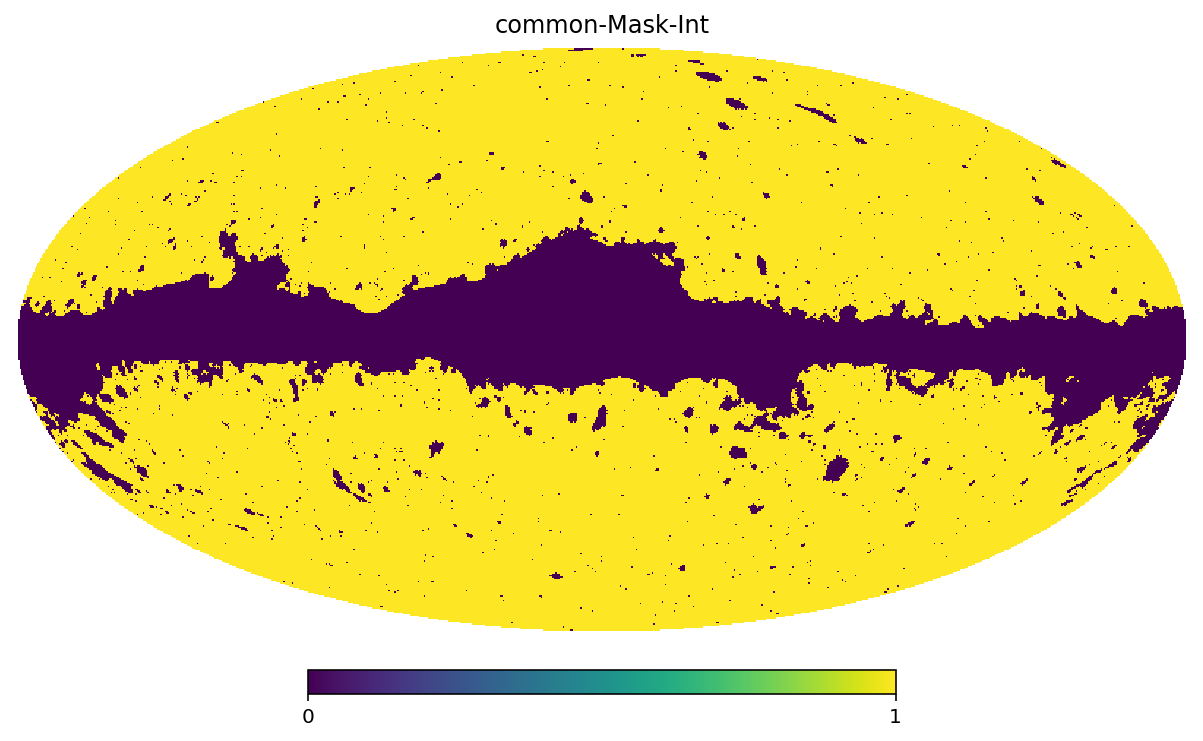

In [3]:
mask = hp.read_map(mask_dir+mask_name)
if rotate:
    rot_gal2ec = hp.Rotator(coord="GE")
    mask = rot_gal2ec.rotate_map_pixel(mask)
if inverted: mask = np.where(mask==0, 1., 0.)
else: mask = np.where(mask==1, 1., 0.)
hp.mollview(mask, title=mask_label)

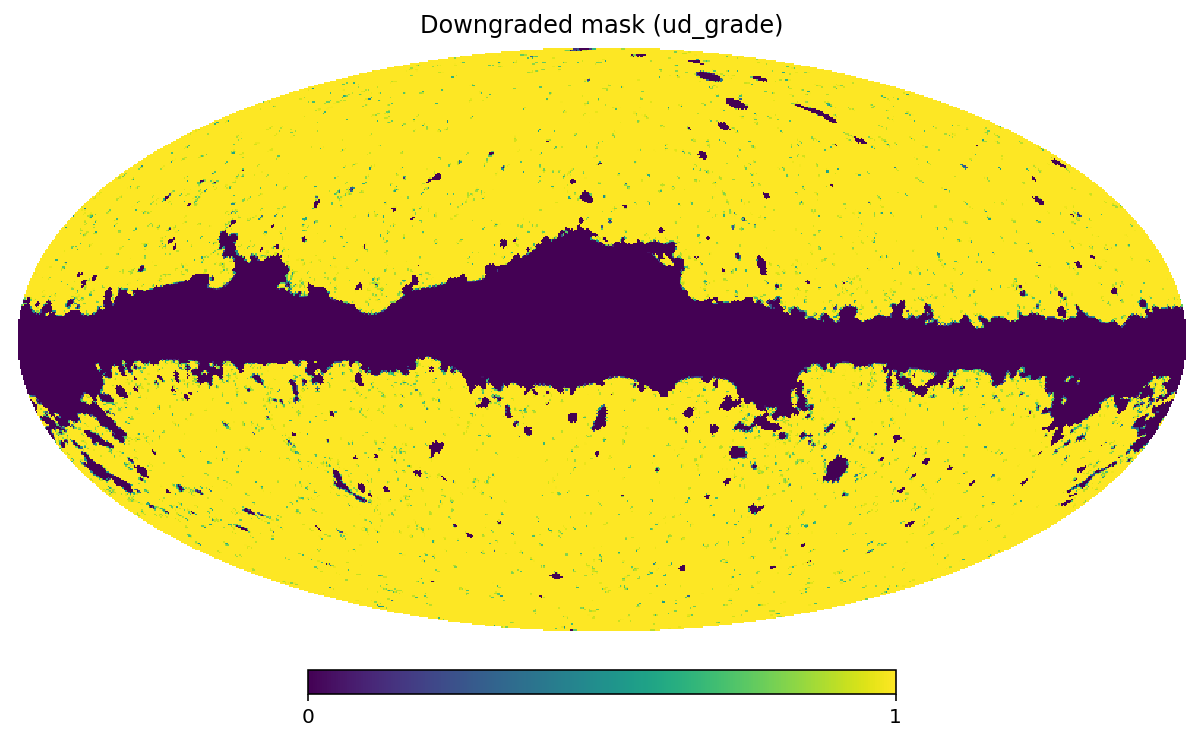

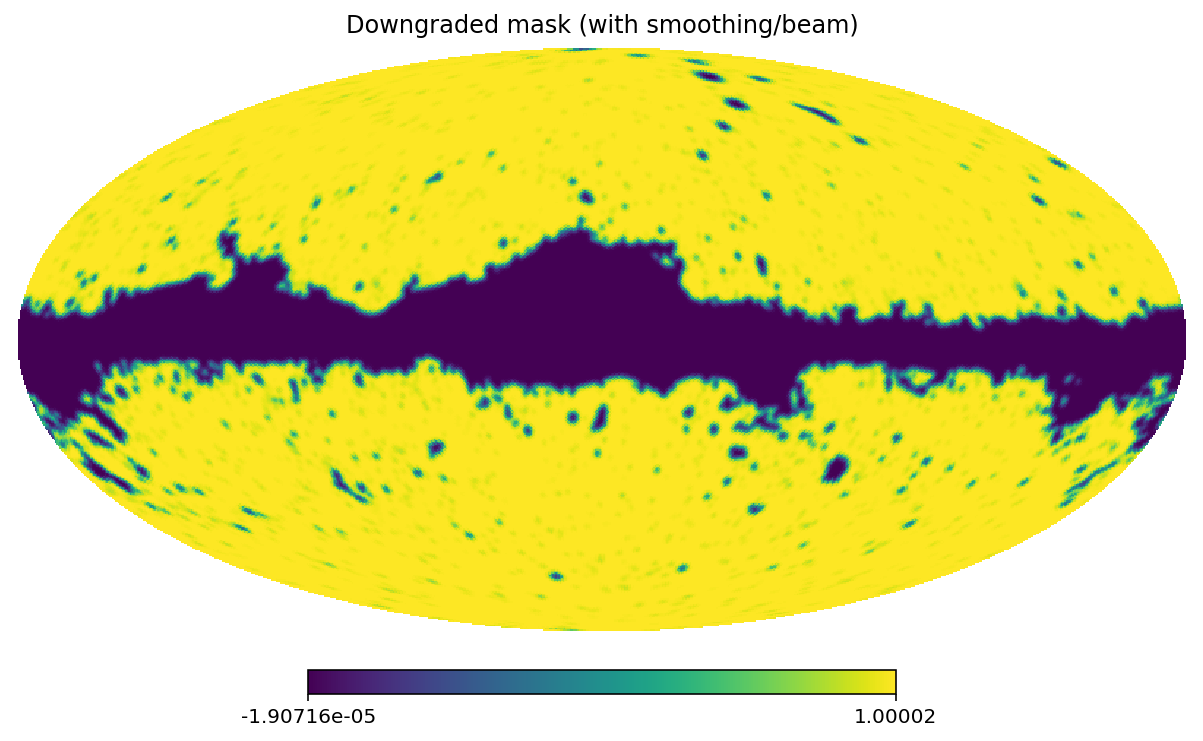

In [4]:
hp.mollview(hp.ud_grade(mask, Nside_out, pess=False), title="Downgraded mask (ud_grade)")
hp.mollview(CMBanom.downgrade_map(mask, Nside_out), title="Downgraded mask (with smoothing/beam)")
if use_udgrade: downgraded_mask = hp.ud_grade(mask, Nside_out, pess=False)
else: downgraded_mask = CMBanom.downgrade_map(mask, Nside_out)

Fraction of masked pixels:
Original high-res. mask: 0.22058812777201334
Pessimistic mask (Nside=128): 0.612152099609375


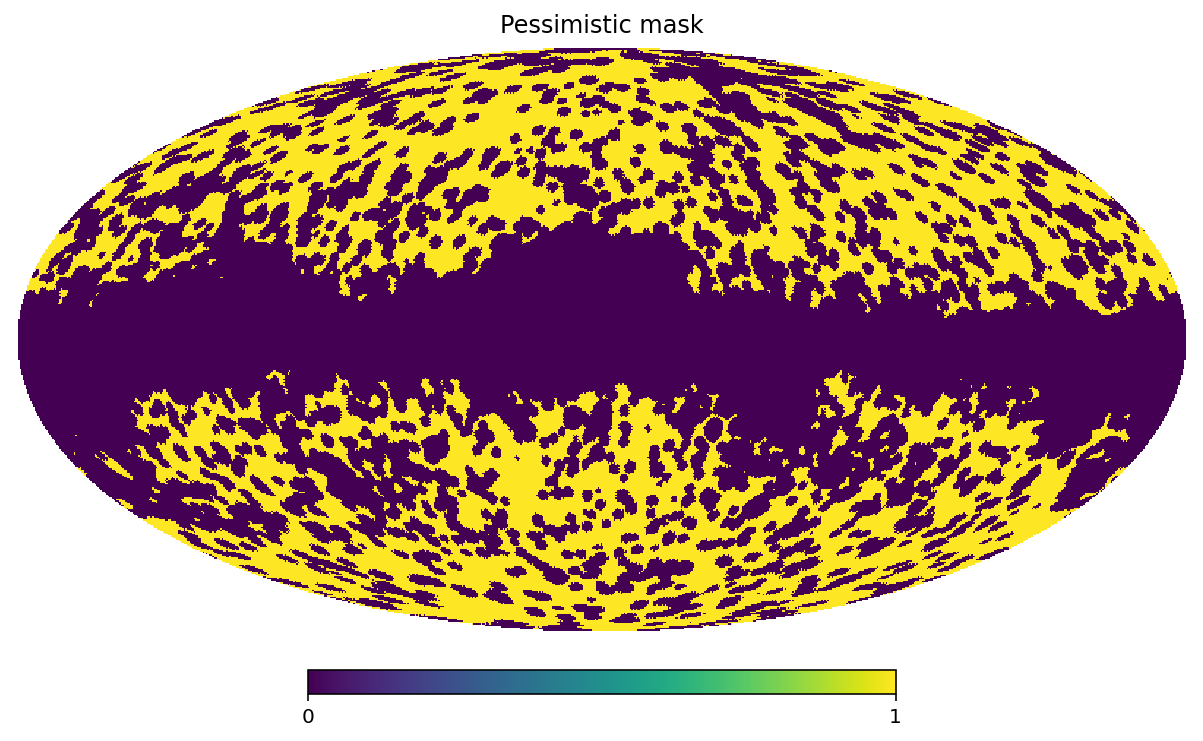

In [5]:
if use_udgrade: pess_mask = np.where(downgraded_mask<1, 0, 1)
else: pess_mask = np.where(downgraded_mask<0.999, 0, 1)
hp.mollview(pess_mask, title="Pessimistic mask")

frac_mask = len(np.nonzero(mask<1)[0])/len(mask)
frac_pess = len(np.nonzero(pess_mask<1)[0])/len(pess_mask)
print("Fraction of masked pixels:")
print("Original high-res. mask:", frac_mask)
print("Pessimistic mask (Nside=128):", frac_pess)

In [6]:
def diff_fraction(cutoff, mask):
    return len(np.nonzero(mask<cutoff)[0])/len(mask)-frac_mask
print(diff_fraction(1, downgraded_mask))

0.7057119210561117


In [7]:
conserv_cutoff = fsolve(diff_fraction, 0.55, downgraded_mask)[0]
print(conserv_cutoff)

0.6106515737611694


/Users/lherold/Applications/anaconda3/lib/python3.7/site-packages/scipy/optimize/minpack.py:175: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)


Fraction of masked pixels:
Original high-res. mask: 0.22058812777201334
Masked-fraction conserving mask: 0.22058614095052084


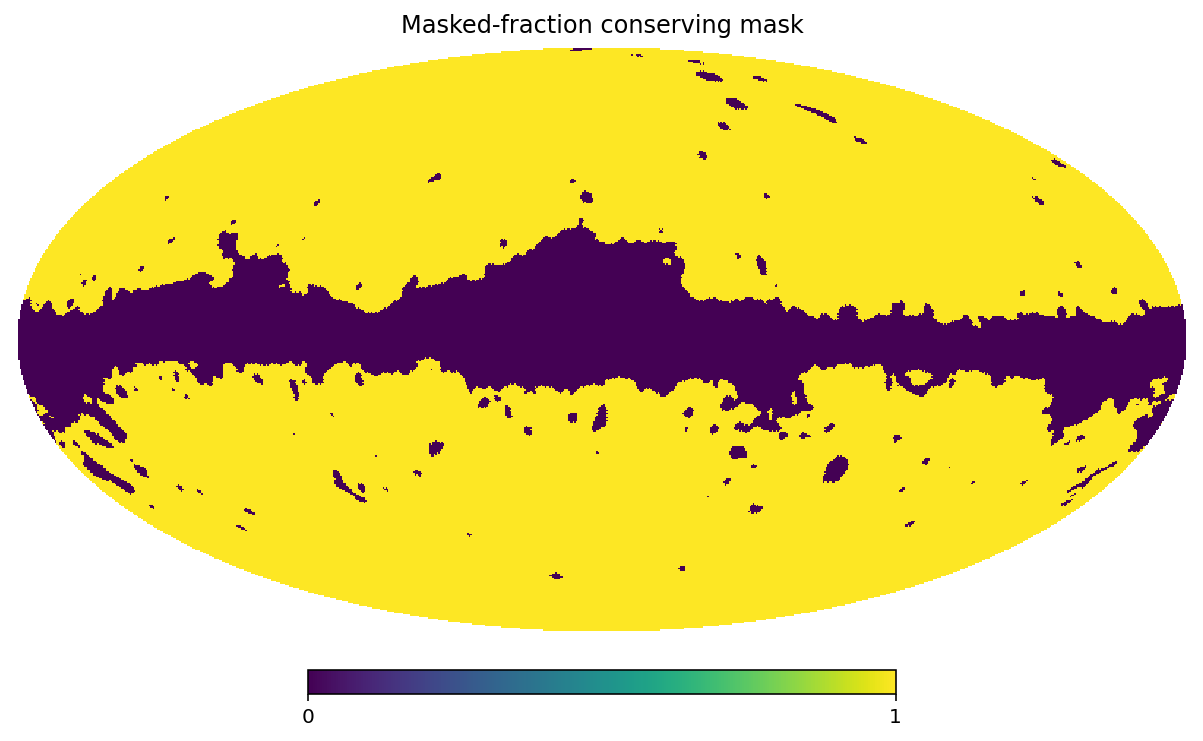

In [8]:
conserv_mask = np.where(downgraded_mask<conserv_cutoff, 0, 1)
hp.mollview(conserv_mask, title="Masked-fraction conserving mask")
frac_conserv = len(np.nonzero(conserv_mask<1)[0])/len(conserv_mask)
print("Fraction of masked pixels:")
print("Original high-res. mask:", frac_mask)
print("Masked-fraction conserving mask:", frac_conserv)

"Planck 2018 results. VII. Isotropy and statistics of the CMB" uses cutoff of 0.9

Fraction of masked pixels:
Original high-res. mask: 0.22058812777201334
Pessimistic mask (Nside=128): 0.612152099609375
Custom mask (cutoff=0.9, Nside=128): 0.263763427734375


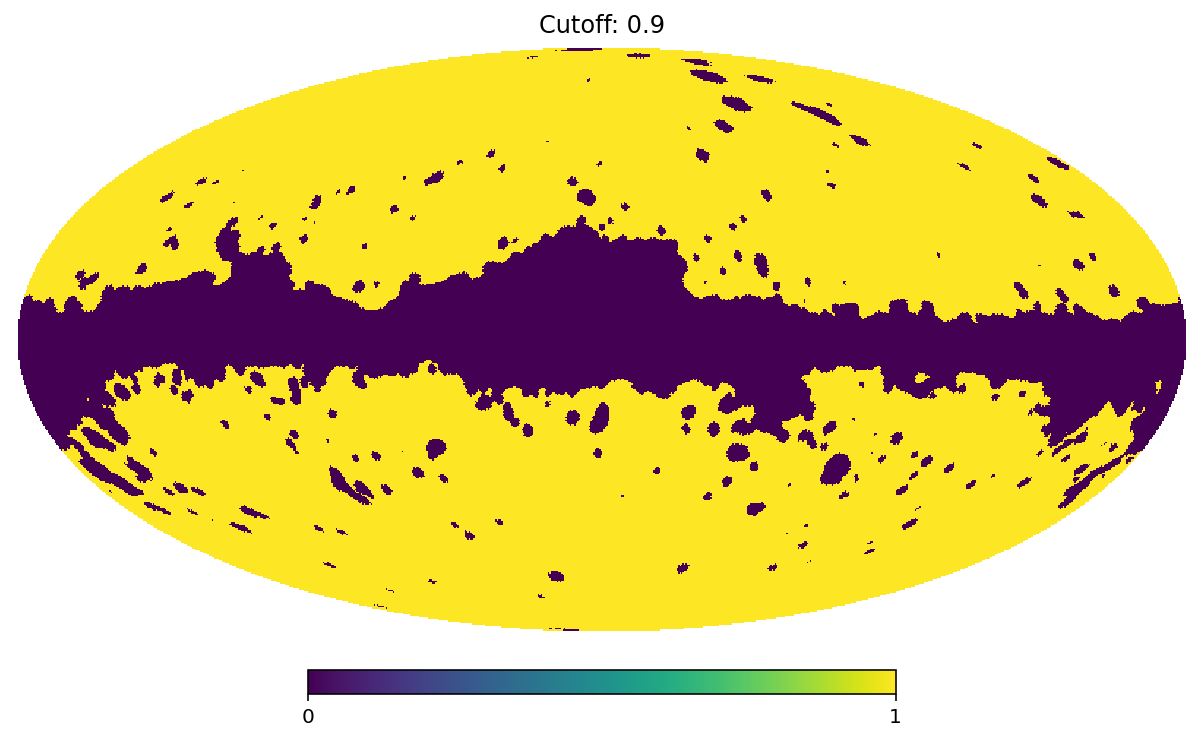

In [9]:
custom_cutoff = 0.9
custom_mask = np.where(downgraded_mask>custom_cutoff, 1, 0)
hp.mollview(custom_mask, title="Cutoff: "+str(custom_cutoff))
#hp.mollview(downgraded_mask, title="Downgraded mask")

frac_custom = len(np.nonzero(custom_mask<1)[0])/len(custom_mask)
print("Fraction of masked pixels:")
print("Original high-res. mask:", frac_mask)
print(f"Pessimistic mask (Nside={Nside_out}):", frac_pess)
print(f"Custom mask (cutoff={custom_cutoff}, Nside={Nside_out}):", frac_custom)

In [10]:
if save_mask:
    if use_udgrade:
        #hp.write_map(mask_dir+mask_label+"_pess_udgrade_Nside"+str(Nside_out)+".fits", pess_mask, overwrite=True, dtype=np.float64)
        hp.write_map(mask_dir+mask_label+"_cutoff"+str(custom_cutoff)+"_udgrade_Nside"+str(Nside_out)+".fits", custom_mask, overwrite=True, dtype=np.float64)
        #hp.write_map(mask_dir+mask_label+"_fraccons_udgrade"+"_Nside"+str(Nside_out)+".fits", conserv_mask, overwrite=True, dtype=np.float64)
    
    else:
        #hp.write_map(mask_dir+mask_label+"_pess_Nside"+str(Nside_out)+".fits", pess_mask, overwrite=True, dtype=np.float64)
        hp.write_map(mask_dir+mask_label+"_cutoff"+str(custom_cutoff)+"_Nside"+str(Nside_out)+".fits", custom_mask, overwrite=True, dtype=np.float64)
        #hp.write_map(mask_dir+mask_label+"_frac_cons"+"_Nside"+str(Nside_out)+".fits", conserv_mask, overwrite=True, dtype=np.float64)


## Save ecliptic mask

In [11]:
# mask_south_ecl = np.append(np.ones(len(mask)//2), np.zeros(len(mask)//2))
# rot_ec2gal = hp.Rotator(coord="EG")
# mask_south_ecl = rot_ec2gal.rotate_map_pixel(mask_south_ecl)
# downgr_mask_south_ecl = hp.ud_grade(mask_south_ecl, Nside_out)
# pess_mask_south_ecl = np.where(downgr_mask_south_ecl>custom_cutoff, 1, 0)
# hp.mollview(pess_mask_south_ecl*custom_mask, title="Mask southern ecliptic * 1perc mask")

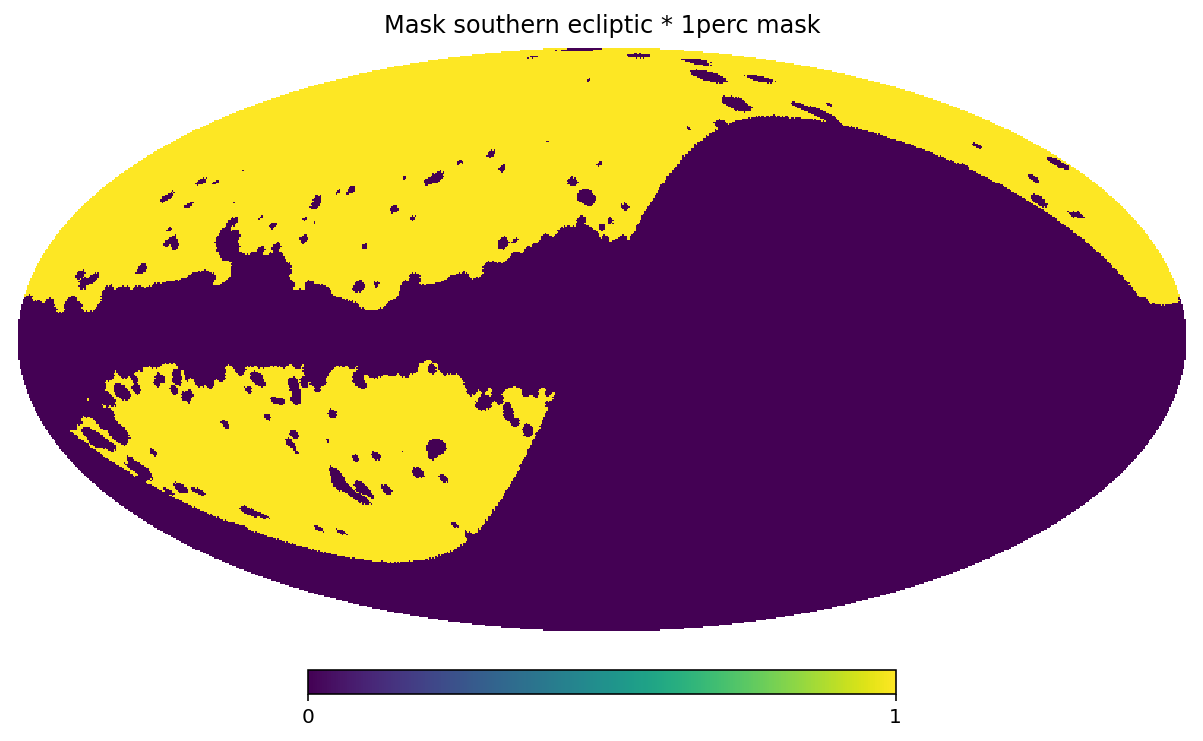

In [12]:
mask_south_ecl = np.append(np.ones(len(pess_mask)//2), np.zeros(len(pess_mask)//2))
rot_ec2gal = hp.Rotator(coord="EG")
mask_south_ecl = rot_ec2gal.rotate_map_pixel(mask_south_ecl)
pess_mask_south_ecl = np.where(mask_south_ecl>custom_cutoff, 1, 0)
hp.mollview(pess_mask_south_ecl*custom_mask, title="Mask southern ecliptic * 1perc mask")

In [13]:
if save_mask: hp.write_map(mask_dir+"mask_south_ecl_"+"Nside"+str(Nside_out)+".fits", pess_mask_south_ecl, overwrite=True, dtype=np.float64)

In [14]:
print(np.where(mask==0))

(array([ 15609,  15610,  15965, ..., 159098, 159099, 159610]),)
